# Heat exchanger

<img src = "./model.svg" width=150px>

## Cocurrent flow

The following scheme is assumed for the tubular heat exchanger operated in cocurrent flow:

<img src = "./images/heatexchanger_dia.png" width=600px>

The cell mesh model for cell $i$ looks like this:

<img src = "./images/heatexchanger_model.png" width=350px>

## Cocurrent flow model equations 

The conservation equations for mass and energy lead to the following differential equations.

\begin{align*}
V_1 \rho_1 C_{p,1}\frac{dT_{1,i}}{dt} & = \dot{m_1} C_{p,1} T_{1,i-1}-\dot{m_1} C_ {p,1}T_{1,i} + UA(T_{2,i}-T_{1,i}) \\
V_2 \rho_2 C_{p,2}\frac{dT_{2,i}}{dt} & = \dot{m_2} C_{p,2} T_{2,i-1}-\dot{m_1} C_ {p,1}T_{2,i} - UA(T_{2,i}-T_{1,i}) \\
\end{align*}

The state variables of the system are the temperatures $T_{1,i}$ and $T_{2,i}$ of the respective fluids in the cells $i$.

Normalizing the equations results in the rates of change over time of $T_1$, and $T_2$.

\begin{align*}
\frac{dT_{1,i}}{dt} & = \frac{\dot{m_1} C_{p,1} (T_{1,i-1}-T_{1,i}) + UA(T_ {2,i}-T_{1,i})}{V_1 \rho_1 C_{p,1}} \\
\frac{dT_{2,i}}{dt} & = \frac{\dot{m_2} C_{p,2} (T_{2,i-1}-T_{2,i}) - UA(T_ {2,i}-T_{1,i})}{V_2 \rho_2 C_{p,2}} \\
\end{align*}

The cross-sectional area $A_1$ of the inner tube is $A_1= \pi r_1^2$. The effective cross-sectional area $A_2$ of the outer tube is $A_2= \pi (r_2^2 - r_1^2)$.

If the tube is now divided into $n$ sections, a reactor length of $L$ results in a partial volume of $V_1=A_1 \cdot \Delta x$ or $V_2=A_2 \cdot \Delta x$ with $\Delta x = L/n$.

The heat transfer surface $A$ between the inner and the outer tube results from the length $\Delta x$ of a section and the inner tube diameter $r_1$ to $A = 2\pi r_1 \Delta x$. The mass flows $\dot{m_1}$ and $\dot{m_2}$ can be represented as $\dot{m_i} = q_i \cdot \rho_i$ with $q_i$ as the corresponding volume flow. This results in the following representation:

\begin{align*}
\frac{dT_{1,i}}{dt} & = \frac{q_1 \rho_1 C_{p,1} (T_{1,i-1}-T_{1,i}) + U 2\pi r_1 \Delta x(T_{2,i}-T_{1,i})}{\pi r_1^2 \Delta x \rho _1 C_{p,1}} \\
\frac{dT_{2,i}}{dt} & = \frac{q_2 \rho_2 C_{p,2} (T_{2,i-1}-T_{2,i}) - U 2\pi r_1 \Delta x(T_{2,i}-T_{1,i})}{\pi (r_2^2 - r_1^2)\Delta x \rho _2 C_{p,2}} \\
\end{align*}

## Countercurrent flow

The direction of flow of the medium $1$ is reversed for the tube heat exchanger operated in counter flow. This means that the exit now becomes an entry and vice versa:

<img src = "./images/heatexchanger_countercurrent_dia.png" width=500px>

The cell network model for cell $i$ then looks like this:

<img src = "./images/heatexchanger_countercurrent_model.png" width=350px>

## Countercurrent flow model equations

It leads to the following differential equations:

\begin{align*}
\frac{dT_{1,i}}{dt} & = \frac{q_1 \rho_1 C_{p,1} (T_{1,i+1}-T_{1,i}) + U 2\pi r_1 \Delta x(T_{2,i}-T_{1,i})}{\pi r_1^2 \Delta x \rho _1 C_{p,1}} \\
\frac{dT_{2,i}}{dt} & = \frac{q_2 \rho_2 C_{p,2} (T_{2,i-1}-T_{2,i}) - U 2\pi r_1 \Delta x(T_{2,i}-T_{1,i})}{\pi (r_2^2 - r_1^2)\Delta x \rho _2 C_{p,2}} \\
\end{align*}

## Parameters of the model

The equations with the following parameters can be integrated using the forward Euler method or with the help of *odeint*.

| Parameter | Symbol | Value | Unit | 
| :------- | :----: | :---: | :---- |
| Length of tube | $L$ | 80.0 | m |
| Inner radius | $r_1$ | 0.1 | m |
| Feed stream inside | $q_1$ | 0.003 | m³/s |
| Density of the inner fluid | $\rho_1$ | 1000.0 | kg/m³ |
| Heat capacity inside | $C_{p,1}$ | 239.0 | J/kg/K |
| Feed temperature inside | $T_{1,f}$ | 400.0 | K |
| Outer Radius | $r_2$ | 0.15 | m |
| Feed stream outside | $q_2$ | 0.005 | m³/s |
| Density of the outer fluid | $\rho_2$ | 1000.0 | kg/m³ |
| Heat capacity outside | $C_{p,2}$ | 4180.0 | J/kg/K |
| Feed temperature outside | $T_{2,f}$ | 280.0 | K |
| Starting temperature in the entire heat exchanger | $T_0$ | 300.0 | K |
| Heat transfer coefficient | $U$ | 280.0 | W/m²/K |

## Implementation of the model


In [9]:
from simunetcore import Model
import numpy as np
import math
from scipy.integrate import odeint  

# Model implementation for the Heatexchanger
class HeatExchanger(Model):
    
    def __init__(self, name:str=""):
        Model.__init__(self, name)
        # Model parameters
        self.params = {
            # Parameters inner pipe
            "r_1"   : {"value": 0.025, "description": "Inner pipe radius", "unit": "m"},
            "C_p_1" : {"value": 239.0, "description": "Heat capacity of inner fluid", "unit": "J/kg/K"},
            "rho_1" : {"value": 1000.0, "description": "Densitiy of inner fluid", "unit": "kg/m^3"},
            # Parameters outer pipe
            "r_2"   : {"value": 0.05, "description": "Outer pipe radius", "unit": "m"},
            "C_p_2" : {"value": 239.0, "description": "Heat capacity of outer fluid", "unit": "J/kg/K"},
            "rho_2" : {"value": 1000.0, "description": "Densitiy of outer fluid", "unit": "kg/m^3"},
            # Parameters heatexchanger
            "L"     : {"value": 30.0, "description": "Pipe length", "unit": "m"},
            "z"     : {"value": 25, "description": "Number of cells", "unit": "-"},
            "U"     : {"value": 340.0, "description": "Heat transfer coefficient", "unit": "W/m^2/K"},         
            "mode"  : {"value": "cocurrent", "description": "Mode of operation (countercurrent, cocurrent)", "unit": "-"}, 
            # ODE solver parameter
            "abserr": {"value": 1.0e-8, "description": "Absolute tolerance", "unit": "-"},
            "relerr": {"value": 1.0e-6, "description": "Relative tolerance", "unit": "-"}
        }
        # Model variables
        self.vars = {
            "q_1_f" : {"description": "Feed flow rate inner pipe", "unit": "m^3/s"}, 
            "T_1_f" : {"description": "Feed temperature inner pipe", "unit": "K"}, 
            "T_1_o" : {"description": "Outlet Temp. inner pipe", "unit": "K"}, 
            "T_1"   : {"description": "Temperature inner pipe", "unit": "K"}, 
            "q_2_f" : {"description": "Feed flow rate outer pipe", "unit": "m^3/s"},
            "T_2_f" : {"description": "Feed temperature outer pipe", "unit": "K"},
            "T_2_o" : {"description": "Outlet Temp. outer pipe", "unit": "K"},
            "T_2"   : {"description": "Temperature outer pipe", "unit": "K"}
        }
        # Model inputs
        self.u = {
            "u_1"   : {"type": "liquid", "description": "Inner pipe feed input", "vars": ["q_1_f", "T_1_f"]},
            "u_2"   : {"type": "liquid", "description": "Outer pipe feed input", "vars": ["q_2_f", "T_2_f"]}
        }
        # Model outputs
        self.y = {
            "y_1"   : {"type": "liquid", "description": "Inner pipe output", "vars": ["T_1_o"]},
            "y_2"   : {"type": "liquid", "description": "Outer pipe output", "vars": ["T_2_o"]}
        }
        # Port adjacencies
        self.adj = [
            ["u_1", "y_1"],
            ["u_2", "y_2"]
        ]
        
    def compute(self, *args, **kwargs):
        # ODE solver parameter
        abserr = self.get_param("abserr") # Absolute tolerance
        relerr = self.get_param("relerr") # Relative tolerance
        t_frame = self.get_t()            # time frame
        z = self.get_param("z")           # Number of cells
        mode = self.get_param("mode")     # Mode of operation (0=countercurrent, 1=cocurrent)
       
        # Create initial vector
        y_0 = np.zeros(2*z)
        T_1 = self.get_var("T_1")
        T_2 = self.get_var("T_2")
        if len(T_1) == 1:
            T_1 = np.full(z, T_1[0])
        if len(T_2) == 1:
            T_2 = np.full(z, T_2[0])
            
        y_0[0:z] = T_1
        y_0[z:2*z] = T_2
        y_sol = odeint(self.odeint_callback, y_0, t_frame, atol=abserr, rtol=relerr)
        
        # Store results
        self.set_var("T_1", y_sol[-1,0:z])
        self.set_var("T_2", y_sol[-1,z:2*z])
        self.set_var("T_1_o", y_sol[:,0] if mode == 0 else y_sol[:,z-1])
        self.set_var("T_2_o", y_sol[:,2*z-1])
 
    def odeint_callback(self, y, t):
        # Parameters inner pipe
        r_1   = self.get_param("r_1")   # inner pipe radius [m]
        C_p_1 = self.get_param("C_p_1") # heat capacity of inner fluid [J/kg/K]
        rho_1 = self.get_param("rho_1") # densitiy of inner fluid [kg/m³]
        A_1   = math.pi*r_1**2          # cross sectional areas of inner pipe [m²]
        # Parameters outer pipe
        r_2   = self.get_param("r_2")   # outer pipe radius [m]
        C_p_2 = self.get_param("C_p_2") # heat capacity of inner fluid [J/kg/K]
        rho_2 = self.get_param("rho_2") # densitiy of outer fluid [kg/m³]
        A_2   = math.pi*r_2**2-A_1      # cross sectional areas of outer pipe [m²]    
        # Parameters heatexchanger
        L     = self.get_param("L")     # pipe length [m]
        z     = self.get_param("z")     # number of cells [-]
        U     = self.get_param("U")     # overall heat transfer coefficient [W/m²/K]
        mode  = self.get_param("mode")  # Mode of operation (0=countercurrent, 1=cocurrent) [-]
        dx    = L/z                     # node width [m]
        A     = 2.0*math.pi*r_1*dx      # heat exchange area between inner and outer pipe# inner pipe
        
        # State variables
        T_1 = y[0:z]
        T_2 = y[z:2*z]
        dy = np.zeros(2*z)
        
        # Coupling vector
        q_1_f = self.get_var("q_1_f", t)
        T_1_f = self.get_var("T_1_f", t)
        q_2_f = self.get_var("q_2_f", t)
        T_2_f = self.get_var("T_2_f", t)
       
        # Differential equations
        if mode == "countercurrent":
            # Counter current heatexchanger inner pipe
            dy[0:z-1] = (q_1_f*rho_1*C_p_1*(T_1[1:z]-T_1[0:z-1]) + U*A*(T_2[0:z-1]-T_1[0:z-1])) / (rho_1*C_p_1*dx*A_1)
            dy[z-1] = (q_1_f*rho_1*C_p_1*(T_1_f-T_1[z-1]) + U*A*(T_2[z-1]-T_1[z-1])) / (rho_1*C_p_1*dx*A_1)

            # Counter current heatexchanger outer pipe
            dy[z+1:2*z] = (q_2_f*rho_2*C_p_2*(T_2[0:z-1]-T_2[1:z]) - U*A*(T_2[1:z]-T_1[1:z])) / (rho_2*C_p_2*dx*A_2)
            dy[z] = (q_2_f*rho_2*C_p_2*(T_2_f-T_2[0]) - U*A*(T_2[0]-T_1[0])) / (rho_2*C_p_2*dx*A_2)

        elif mode == "cocurrent":
            # Cocurrent heatexchanger inner pipe
            dy[1:z] = (q_1_f*rho_1*C_p_1*(T_1[0:z-1]-T_1[1:z]) + U*A*(T_2[1:z]-T_1[1:z])) / (rho_1*C_p_1*dx*A_1)
            dy[0] = (q_1_f*rho_1*C_p_1*(T_1_f-T_1[0]) + U*A*(T_2[0]-T_1[0])) / (rho_1*C_p_1*dx*A_1)

            # Cocurrent heatexchanger outer pipe
            dy[z+1:2*z] = (q_2_f*rho_2*C_p_2*(T_2[0:z-1]-T_2[1:z]) - U*A*(T_2[1:z]-T_1[1:z])) / (rho_2*C_p_2*dx*A_2)
            dy[z] = (q_2_f*rho_2*C_p_2*(T_2_f-T_2[0]) - U*A*(T_2[0]-T_1[0])) / (rho_2*C_p_2*dx*A_2)
        else:
            raise AttributeError("mode")
        return dy    

## Computation of the model

In [10]:
# Create the model
M_2 = HeatExchanger("M_2")
M_2.set_param("mode", "cocurrent")

# Setup integration time
t_start = 0.0
t_end = 200.0
numpoints = 101
M_2.set_t(np.linspace(t_start, t_end, numpoints))

# Setup inital values
z = M_2.get_param("z")
M_2.set_var("T_1", [300])
M_2.set_var("T_2", [300])

# Setup imput vector
q_1_f = np.full(numpoints, 100/1000/60)
T_1_f = np.full(numpoints, 373.15)
q_2_f = np.full(numpoints, 100/1000/60)
T_2_f = np.full(numpoints, 300.0)

u_1 = [q_1_f, T_1_f]
u_2 = [q_2_f, T_2_f]
M_2.set_u("u_1", u_1)
M_2.set_u("u_2", u_2)

# Solve model
M_2.compute()

## Results

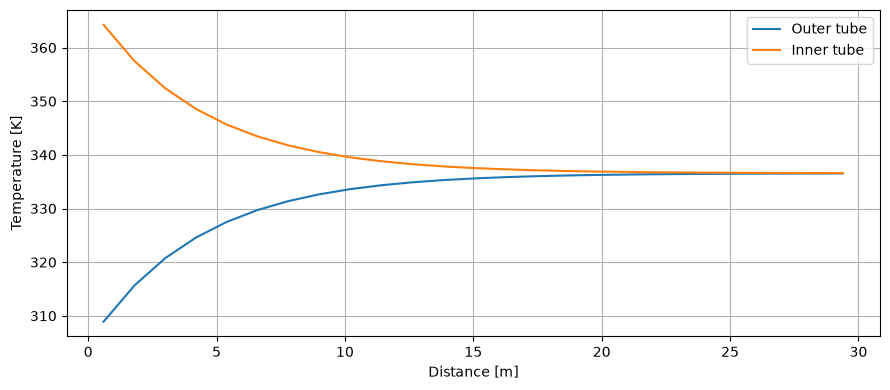

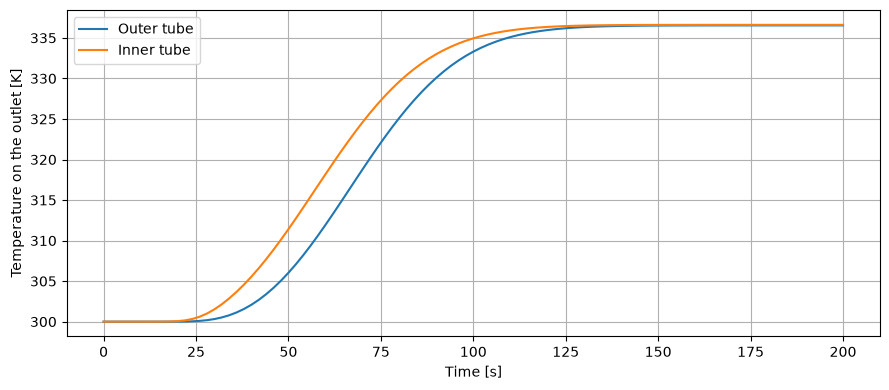

In [11]:
import matplotlib.pyplot as plt

# Plot results
L= M_2.get_param("L")
dx = L/z
x = np.linspace(dx/2, L-dx/2, z)
plt.figure(figsize=(9, 4))
plt.plot(x, M_2.get_var("T_2"), label="Outer tube")
plt.plot(x, M_2.get_var("T_1"), label="Inner tube")
plt.xlabel("Distance [m]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot result
plt.figure(figsize=(9, 4))
plt.plot(M_2.get_t(), M_2.get_var("T_2_o"), label="Outer tube")
plt.plot(M_2.get_t(), M_2.get_var("T_1_o"), label="Inner tube")
plt.xlabel("Time [s]")
plt.ylabel("Temperature on the outlet [K]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()